# Variant analysis

In [1]:
import pandas as pd
import cyvcf2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Filtering only associative variant sites
This is the union of all 7 non-SBC11 sharing groups (SBC4, SBC10, SBC23, SBC4_SBC10, SBC4_SBC23, SBC10_SBC23, SBC4_SBC10_SBC23). Condition: SBC11 absent AND at least one other present.

In [86]:
!../docker/run.sh bcftools view -Oz -i 'GT[2]!="alt" && (GT[0]="alt" || GT[1]="alt" || GT[3]="alt")' ../results/combined/all.annotated.vcf.gz -o ../analysis/data/notSBC11.vcf.gz
!../docker/run.sh bcftools index -t ../analysis/data/notSBC11.vcf.gz

## Parse VCF into pandas dataframe

In [2]:
ANN_FIELDS = [
    "ann_allele", "ann_effect", "ann_impact", "ann_gene_name", "ann_gene_id",
    "ann_feature_type", "ann_feature_id", "ann_biotype", "ann_rank",
    "ann_hgvs_c", "ann_hgvs_p", "ann_cdna_pos", "ann_cds_pos", "ann_aa_pos",
    "ann_distance", "ann_extra",
]

SIFT_FIELDS = [
    "sift_allele", "sift_transcript", "sift_gene_id", "sift_gene_name",
    "sift_region", "sift_variant_type", "sift_aa_change", "sift_aa_pos",
    "sift_score", "sift_median", "sift_num_seqs", "sift_allele_type",
    "sift_prediction",
]

# Sniffles2 INFO keys -> sniffles_-prefixed column names (same nomenclature as ANN/SIFT)
SNIFFLES_KEY_MAP = {
    "SVTYPE": "sniffles_svtype", "SVLEN": "sniffles_svlen", "END": "sniffles_end",
    "SUPPORT": "sniffles_support", "SUPP_VEC": "sniffles_supp_vec",
    "STRAND": "sniffles_strand", "AF": "sniffles_af",
    "STDEV_POS": "sniffles_stdev_pos", "STDEV_LEN": "sniffles_stdev_len",
    "COVERAGE": "sniffles_coverage", "PRECISE": "sniffles_precise",
    "IMPRECISE": "sniffles_imprecise", "MOSAIC": "sniffles_mosaic",
}
SNIFFLES_FIELDS = list(SNIFFLES_KEY_MAP.values())

# Numeric/flag INFO columns to cast from string -> real dtype after parsing
# (dtypes taken from the VCF header: Type=Integer/Float, Type=Flag). Nullable
# Int64/float tolerate the NaNs left by SNP rows (no sniffles_*) and non-coding
# sites (no sift_*). SUPP_VEC/STRAND/COVERAGE stay strings on purpose ("0100"
# leading zeros, "+-", "48,11,..." Number=. list).
INT_COLS   = ["sniffles_svlen", "sniffles_end", "sniffles_support",
              "sift_aa_pos", "sift_num_seqs", "ann_distance"]
FLOAT_COLS = ["sniffles_af", "sniffles_stdev_pos", "sniffles_stdev_len",
              "sift_score", "sift_median"]
FLAG_COLS  = ["sniffles_precise", "sniffles_imprecise", "sniffles_mosaic"]

# SIFT4G writes DELETERIOUS (score < 0.05) or TOLERATED; NA means non-coding
_SIFT_PRIORITY = {"DELETERIOUS": 0, "TOLERATED": 1}
# impact severity for tiebreaking (HIGH most severe -> lowest rank)
_IMPACT_RANK = {"HIGH": 0, "MODERATE": 1, "LOW": 2, "MODIFIER": 3}


def _parse_info_kv(info_str):
    """Split a raw INFO string into a flat dict.
    'KEY=VALUE' -> {KEY: VALUE} (split on first '=' only), bare flags -> {FLAG: True}."""
    kv = {}
    for token in info_str.split(";"):
        if "=" in token:
            k, v = token.split("=", 1)
            kv[k] = v
        elif token:
            kv[token] = True
    return kv


def parse_info(info_str):
    """Parse a raw VCF INFO string into a structured dict.

    Returns is_sv (True for Sniffles2 SV records), ann_raw / sift_raw (the raw
    ANN= / SIFTINFO= strings, or None), and the Sniffles2 fields renamed with a
    sniffles_ prefix (None when absent / non-SV record). ann_raw / sift_raw are
    consumed by parse_vcf to explode them into ann_* / sift_* columns.
    """
    kv = _parse_info_kv(info_str)
    result = {
        "is_sv":    "SVTYPE" in kv,
        "ann_raw":  kv.get("ANN"),
        "sift_raw": kv.get("SIFTINFO"),
    }
    for vcf_key, col in SNIFFLES_KEY_MAP.items():
        result[col] = kv.get(vcf_key)        # None when absent
    return result


def _parse_ann(raw):
    """Split a SnpEff ANN= string into a list of dicts (one per ANN entry)."""
    records = []
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(ANN_FIELDS) - len(parts))
        records.append(dict(zip(ANN_FIELDS, parts[:len(ANN_FIELDS)])))
    return records


def _parse_siftinfo(raw):
    """Map (allele, transcript) -> best SIFT record from a SIFTINFO= string.

    SnpEff ann_feature_id and SIFT sift_transcript share the XM_* namespace, so
    they join directly. On duplicate keys, DELETERIOUS beats TOLERATED.
    """
    by_key = {}
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(SIFT_FIELDS) - len(parts))
        d = dict(zip(SIFT_FIELDS, parts[:len(SIFT_FIELDS)]))
        key = (d["sift_allele"], d["sift_transcript"])
        pred = d.get("sift_prediction", "")
        current = by_key.get(key)
        if current is None or _SIFT_PRIORITY.get(pred, 99) < _SIFT_PRIORITY.get(current.get("sift_prediction", ""), 99):
            by_key[key] = d
    return by_key


def _reduce_annotations(annotations, sift_by_key):
    """Reduce a variant's many ANN entries to ONE per gene (see genomics_scoring.py).

    Deterministic sort (lowest key wins): (1) SIFT match on (allele, transcript),
    (2) impact severity HIGH>MODERATE>LOW>MODIFIER, (3) original ANN order,
    (4) protein_coding over other biotypes. Returns (ann, sift) pairs, one per gene.
    """
    by_gene = {}
    for order, ann in enumerate(annotations):
        key = (ann.get("ann_allele", ""), ann.get("ann_feature_id", ""))
        sort_key = (
            0 if key in sift_by_key else 1,
            _IMPACT_RANK.get(ann.get("ann_impact", ""), 99),
            order,
            0 if ann.get("ann_biotype") == "protein_coding" else 1,
        )
        by_gene.setdefault(ann.get("ann_gene_id", ""), []).append((sort_key, key, ann))

    reduced = []
    for entries in by_gene.values():
        _, key, ann = min(entries, key=lambda t: t[0])
        reduced.append((ann, sift_by_key.get(key, {})))
    return reduced


def _fmt_gt(gt):
    """cyvcf2 genotype list -> VCF-style string: [1, 1, False] -> '1/1',
    [0, 1, True] -> '0|1', missing alleles (-1) -> '.'. Handles haploid too."""
    *alleles, phased = gt
    sep = "|" if phased else "/"
    return sep.join("." if a < 0 else str(a) for a in alleles)


def parse_vcf(vcf_path):
    """Parse an annotated VCF into a tidy DataFrame — one row per (variant, gene).

    Per row: chrom, pos, ref, alt, qual, filter; one GT column per sample;
    is_sv and the sniffles_* fields (None for SNP/indels); the SnpEff ANN entry
    exploded into ann_* columns (one per gene via _reduce_annotations); and the
    matching SIFT4G record exploded into sift_* columns. Records without ANN
    (e.g. the ~0.24% of SVs lacking SnpEff annotation) emit a single row with no
    ann_*/sift_* fields. No scoring is applied.

    INFO-derived columns arrive as strings/None; INT_COLS/FLOAT_COLS/FLAG_COLS
    are cast to nullable Int64 / float64 / bool before returning.
    """
    vcf = cyvcf2.VCF(vcf_path)
    samples = vcf.samples
    rows = []
    for v in vcf:
        base = {
            "chrom":  v.CHROM,
            "pos":    v.POS,
            "ref":    v.REF,
            "alt":    ",".join(v.ALT),
            "qual":   v.QUAL,
            "filter": v.FILTER,
        }
        base.update(zip(samples, map(_fmt_gt, v.genotypes)))

        info = parse_info(";".join(
            k if val is True else f"{k}={val}" for k, val in v.INFO
        ))
        ann_raw = info.pop("ann_raw")
        sift_raw = info.pop("sift_raw")
        base.update(info)                    # is_sv + sniffles_* columns

        if not ann_raw:
            rows.append(base)
            continue

        annotations = _parse_ann(ann_raw)
        sift_by_key = _parse_siftinfo(sift_raw) if sift_raw else {}
        for ann, sift in _reduce_annotations(annotations, sift_by_key):
            rows.append({**base, **ann, **sift})

    vcf.close()

    df = pd.DataFrame(rows)
    for col in INT_COLS:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    for col in FLOAT_COLS:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in FLAG_COLS:
        if col in df:
            df[col] = df[col].notna()        # flag present -> True, else False
    
    df["sift_score"] = pd.to_numeric(df.get("sift_score"), errors="coerce")
    df["sift_score_c"] = 1 - df["sift_score"]
    return df

IMPACT_BANDS = {
    "MODIFIER": (0.00, 0.25),
    "LOW":      (0.25, 0.50),
    "MODERATE": (0.50, 0.75),
    "HIGH":     (0.75, 1.00),
}

def scoring(df: pd.DataFrame) -> pd.DataFrame:
    lo = df["ann_impact"].map(lambda i: IMPACT_BANDS.get(i, (np.nan, np.nan))[0])
    hi = df["ann_impact"].map(lambda i: IMPACT_BANDS.get(i, (np.nan, np.nan))[1])
    width = hi - lo

    score = lo + 0.5 * width # band midpoint default

    refine = df["ann_impact"].eq("MODERATE") & df["sift_score_c"].notna()
    score = score.mask(refine, lo + df["sift_score_c"] * width) # SIFT within MODERATE only

    df["score"] = score
    return df

def _append_rank(out: pd.DataFrame) -> pd.DataFrame:
    """Insert ``percentile`` and ``rank`` columns immediately right of ``score``.

    ``rank`` is 1 = highest score (dense ranking on ties); ``percentile`` is the
    score's position in [0, 100], higher score -> higher percentile. NaN scores
    (no length/effect match) get NaN rank and percentile. Assumes ``out`` is
    already sorted by score descending.
    """
    percentile = out["score"].rank(ascending=True, pct=True) * 100
    rank = out["score"].rank(ascending=False, method="dense").astype("Int64")
    pos = out.columns.get_loc("score") + 1
    out.insert(pos, "percentile", percentile)
    out.insert(pos + 1, "rank", rank)
    return out

def merge_to_gene_max(df_scored: pd.DataFrame, gene_key: str = "ann_gene_id") -> pd.DataFrame:
    """Collapse variant/transcript rows to one row per gene.

    Maximum / worst-variant approach: each gene's ``score`` is the score of its
    single most damaging variant. Only gene-level columns (GENE_LEVEL_COLS) are
    emitted; variant-level fields are dropped because the output is a per-gene
    product. Rows with no gene id are dropped.
    """
    scored = df_scored[df_scored[gene_key].fillna("").ne("")]
    idx = scored.groupby(gene_key)["score"].idxmax()       # worst variant per gene
    out = scored.loc[idx]
    return _append_rank(out.sort_values("score", ascending=False))

In [3]:
df_variants = parse_vcf("../analysis/data/notSBC11.vcf.gz")

In [4]:
df_variants = df_variants[(~df_variants['ann_gene_id'].str.contains("-", regex=False, na=False, case=False)) & ~df_variants['ann_gene_id'].str.contains("&", regex=False, na=False, case=False)]
df_variants

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_region,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c
0,NC_012870.2,487,AG,A,52.849998,None,1/1,./.,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
2,NC_012870.2,997,ATACC,A,64.190002,None,1/1,./.,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
4,NC_012870.2,1619,G,A,54.540001,None,./.,1|0,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
6,NC_012870.2,2814,G,GT,28.549999,None,1/1,./.,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
8,NC_012870.2,2830,G,A,34.400002,None,1/1,./.,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925099,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
4925100,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
4925102,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
4925103,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN


## Variant to gene-level annotation
Converting one-row-per-variant data frame into one-row-per-gene:
1. Score each variant's impact (detected by SnpEff and SIFT)
2. Output worst score (maximum) among variants within one gene

In [5]:
df_variants_scored = scoring(df_variants)
df_variants_scored

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012870.2,487,AG,A,52.849998,None,1/1,./.,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
2,NC_012870.2,997,ATACC,A,64.190002,None,1/1,./.,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
4,NC_012870.2,1619,G,A,54.540001,None,./.,1|0,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
6,NC_012870.2,2814,G,GT,28.549999,None,1/1,./.,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
8,NC_012870.2,2830,G,A,34.400002,None,1/1,./.,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925099,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
4925100,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
4925102,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
4925103,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125


In [6]:
df_genes = merge_to_gene_max(df_variants_scored)
df_genes

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score,percentile,rank
4783952,NC_012879.2,47028800,TC,T,35.220001,None,1/1,./.,./.,1/1,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,92.935681,1
4514621,NC_012879.2,3462573,T,TCCTGCGGATGCTTG,28.980000,None,1/1,./.,./.,1/1,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,92.935681,1
1452675,NC_012872.2,25784577,N,N[NC_008360.1:318482[,60.000000,None,0/0,0/0,0/0,0/1,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.875,92.935681,1
4047160,NC_012877.2,59800110,T,TAG,56.779999,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,92.935681,1
317350,NC_012870.2,40606725,N,[NC_008360.1:329419[N,60.000000,None,0/0,0/1,0/0,0/0,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.875,92.935681,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3665712,NC_012877.2,7387382,C,T,22.260000,None,./.,./.,./.,0/1,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,22.508580,104
3665748,NC_012877.2,7451912,G,A,33.220001,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,22.508580,104
4138998,NC_012878.2,3211095,G,A,29.410000,None,1/1,./.,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,22.508580,104
4142287,NC_012878.2,3360790,A,G,35.480000,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,22.508580,104


In [7]:
def plot_kdeplot(df: pd.DataFrame, title: str, ax=None, clip=None):
    """KDE of the per-row/per-gene ``score`` column (mirrors the notebook helper).

    The x-axis starts at the LOW band floor so the spike of MODIFIER scores
    (all pinned at the MODIFIER band midpoint) doesn't flatten the rest of the
    distribution. Ticks sit at the midpoint of each visible impact band and are
    labeled with that band's range (MODIFIER has no tick since its range falls
    entirely outside the clipped view).
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 5))

    x_min = IMPACT_BANDS["LOW"][0]
    x_max = clip[1] if clip is not None else df["score"].max()
    effective_clip = (x_min, x_max)

    sns.kdeplot(
        data=df,
        x="score",
        fill=True,
        clip=effective_clip,
        cut=0,
        bw_adjust=1.0,
        ax=ax,
    )

    ax.set_xlim(effective_clip)

    band_colors = {"MODIFIER": "0.6", "LOW": "tab:blue", "MODERATE": "tab:orange", "HIGH": "tab:red"}
    ticks, ticklabels = [], []
    for band, (lo, hi) in IMPACT_BANDS.items():
        vis_lo, vis_hi = max(lo, x_min), min(hi, x_max)
        if vis_hi > vis_lo:
            ax.axvspan(vis_lo, vis_hi, color=band_colors[band], alpha=0.08, zorder=0)
        mid = (lo + hi) / 2
        if mid >= x_min:
            ticks.append(mid)
            ticklabels.append(f"{band}\n[{lo:.2f}, {hi:.2f})")

    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels)

    ax.set_title(f"Scores distribution on {title}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")

    if own_fig:
        fig.tight_layout()
    return ax

def raw_variant_plotting(df: pd.DataFrame, sample: str, out_path: str) -> str:
    """Render the KDE of the raw, variant-level ``score`` column and save it.

    Unlike plotting_summary (which plots the gene-collapsed MAX/SUM tables), this
    plots every (variant, gene) row's severity score straight from scoring() --
    the input distribution before any gene-level aggregation or length
    normalization. Saves the figure to ``out_path`` and returns that path.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_kdeplot(df, "variant", ax=ax)
    fig.suptitle(f"{sample}: variant-level score distribution", y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path

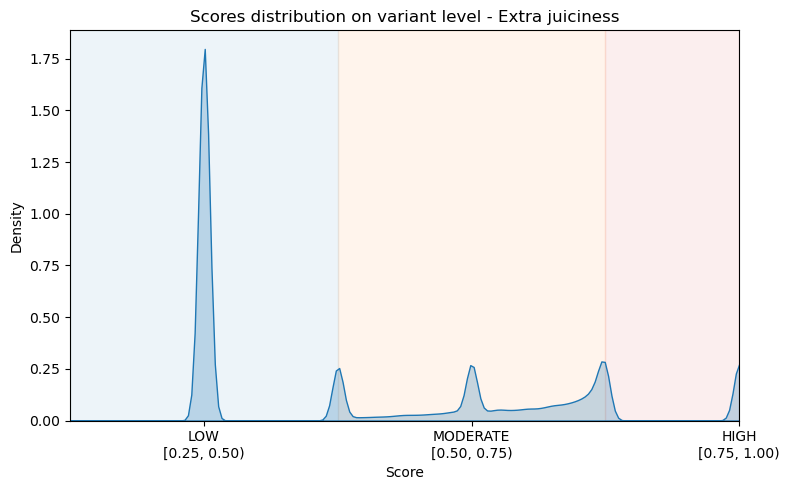

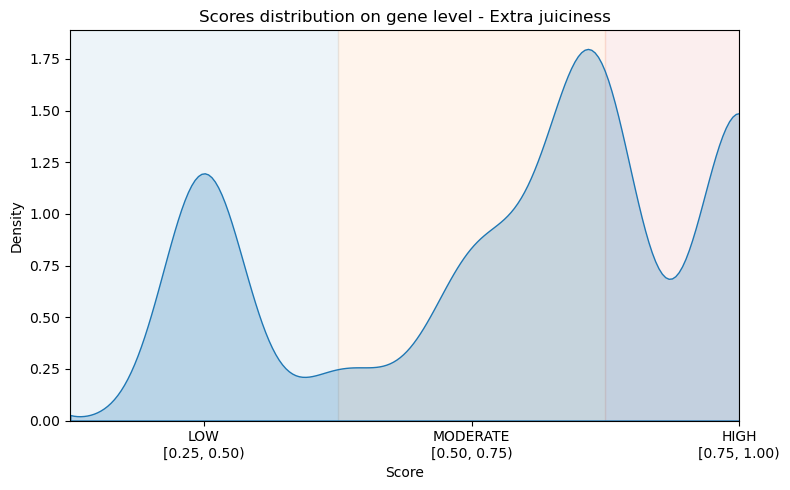

In [8]:
plot_kdeplot(df_variants_scored, "variant level - Extra juiciness")
plt.show()

plot_kdeplot(df_genes, "gene level - Extra juiciness")
plt.show()

# DMR analysis

In [9]:
# DMR_annotated.tsv schema (one row per DMR x overlapping feature x gene):
#   chr, start, end, diff.Methy, direction (= "hyper_<accession>"),
#   sample_a, sample_b, feature (promoter|exon|CDS|intron|intergenic), gene_label
DMR_PATH = Path("../results/DMR/DMR_annotated.tsv")

df_dmr = pd.read_csv(DMR_PATH, sep="\t")
print(f"{len(df_dmr):,} DMR-feature rows | features: {sorted(df_dmr['feature'].unique())}")

# --- Candidate genes: promoter HYPOMETHYLATED in the dry accession SBC11 -------
# SBC11 is the lone dry accession. A promoter LESS methylated in SBC11 than in a
# juicy accession is de-repressed in SBC11 / silenced in the juicy ones -- the
# expression contrast that could underlie the juicy-vs-dry split. So candidates
# are genes whose promoter is hypomethylated in SBC11.
#
# Direction encoding: `direction` names the HYPER accession ("hyper_<acc>").
# Hypomethylated in SBC11  <=>  the contrast involves SBC11 AND the hyper side is
# the OTHER accession, i.e. direction != "hyper_SBC11".
SBC11 = "SBC11"

promoter_dmr = df_dmr[
    (df_dmr["feature"] == "promoter")
    & df_dmr["gene_label"].notna()
    & (df_dmr["gene_label"].astype(str).str.strip() != "")
].copy()

involves_sbc11 = (promoter_dmr["sample_a"] == SBC11) | (promoter_dmr["sample_b"] == SBC11)
hypo_in_sbc11  = involves_sbc11 & (promoter_dmr["direction"] != f"hyper_{SBC11}")
sbc11_hypo = promoter_dmr[hypo_in_sbc11].copy()
sbc11_hypo["abs_diff"] = sbc11_hypo["diff.Methy"].abs()

# one row per gene: its strongest SBC11-hypomethylated promoter DMR
promoter_candidates = (
    sbc11_hypo
    .sort_values("abs_diff", ascending=False)
    .drop_duplicates(subset="gene_label")
    .loc[:, ["gene_label", "diff.Methy", "abs_diff", "direction",
             "sample_a", "sample_b", "chr", "start", "end"]]
    .reset_index(drop=True)
)
print(f"{int(hypo_in_sbc11.sum()):,} promoter DMRs hypomethylated in {SBC11} -> "
      f"{len(promoter_candidates):,} candidate genes")
promoter_candidates.head(20)

152,253 DMR-feature rows | features: ['CDS', 'exon', 'intergenic', 'promoter']
6,961 promoter DMRs hypomethylated in SBC11 -> 5,367 candidate genes


,gene_label,diff.Methy,abs_diff,direction,sample_a,sample_b,chr,start,end
0,LOC110432410,-0.621911,0.621911,hyper_SBC23,SBC11,SBC23,NC_012871.2,9293745,9293880
1,LOC110432674,-0.618042,0.618042,hyper_SBC4,SBC11,SBC4,NC_012871.2,36039726,36039979
2,LOC110437322,-0.569947,0.569947,hyper_SBC4,SBC11,SBC4,NC_012876.2,63484731,63485968
3,LOC110436852,-0.569947,0.569947,hyper_SBC4,SBC11,SBC4,NC_012876.2,63484731,63485968
4,LOC110433273,-0.562994,0.562994,hyper_SBC23,SBC11,SBC23,NC_012872.2,17366045,17366207
5,LOC8074345,-0.554586,0.554586,hyper_SBC23,SBC11,SBC23,NC_012874.2,65779128,65779445
6,LOC8079764,-0.540058,0.540058,hyper_SBC23,SBC11,SBC23,NC_012870.2,22449132,22449709
7,LOC8064491,-0.533174,0.533174,hyper_SBC23,SBC11,SBC23,NC_012870.2,13890142,13890569
8,LOC8062471,-0.530691,0.530691,hyper_SBC23,SBC11,SBC23,NC_012870.2,13225228,13227500
9,LOC8077906,-0.512978,0.512978,hyper_SBC23,SBC11,SBC23,NC_012878.2,45590629,45590874


## Promoter hypomethylated in SBC11 across the dry-vs-juicy contrasts

In [10]:
# --- Refinement: hypomethylated in SBC11 in >=1 dry-vs-juicy contrast --------
# Candidate genes have a promoter hypomethylated in SBC11 in at least one
# SBC11-vs-juicy contrast (mirrors the variant analysis's union-of-groups
# logic, which also doesn't require the signal to hold across all three juicy
# accessions -- just SBC11 absent and at least one juicy sample present).
JUICY = ["SBC4", "SBC10", "SBC23"]

dry_vs_juicy = promoter_dmr[
    ((promoter_dmr["sample_a"] == SBC11) & promoter_dmr["sample_b"].isin(JUICY))
    | ((promoter_dmr["sample_b"] == SBC11) & promoter_dmr["sample_a"].isin(JUICY))
].copy()
dry_vs_juicy["hypo_in_dry"] = dry_vs_juicy["direction"] != f"hyper_{SBC11}"

phenotype_candidates = (
    dry_vs_juicy[dry_vs_juicy["hypo_in_dry"]]
    .groupby("gene_label")
    .agg(n_hypo_dry=("hypo_in_dry", "sum"), mean_diff=("diff.Methy", "mean"))
    .sort_values("mean_diff", key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
print(f"{len(phenotype_candidates)} genes with a promoter hypomethylated in {SBC11} "
      f"in at least one dry-vs-juicy contrast")
phenotype_candidates.head(20)


5367 genes with a promoter hypomethylated in SBC11 in at least one dry-vs-juicy contrast


,gene_label,n_hypo_dry,mean_diff
0,LOC110432674,1,-0.618042
1,LOC110437322,1,-0.569947
2,LOC110436852,1,-0.569947
3,LOC110433273,1,-0.562994
4,LOC8074345,1,-0.554586
5,LOC8064491,1,-0.533174
6,LOC8066993,1,-0.511138
7,LOC8069373,1,-0.510218
8,LOC110429766,1,-0.488298
9,LOC8054594,1,0.485170


# dPCD gene module from literature review

## Conserved dPCD genes
| AGI | Name | Homologs in sorghum (EGI) | Name in sorghum|
|-----|------|---------------------------|----------------|
| AT1G26820 | ribonuclease 3 | LOC8063515 <br> LOC8063317 <br> LOC8077825 | ribonuclease 1 <br> ribonuclease 3 <br> ribonuclease 1 |
| AT1G11190 | bifunctional nuclease i | - | - | 
| AT5G04200 | metacaspase 9 | - | - |
| AT3G45010 | serine carboxypeptidase-like 48 | LOC8074232 | serine carboxypeptidase-like |
| AT1G62290 | Saposin-like aspartyl protease family protein | LOC8058198 <br> LOC110430277 <br> LOC110433911 | aspartic proteinase oryzasin-1 <br> aspartic proteinase-like <br> aspartic proteinase-like |



## Broader dPCD genes, Ath-Sbi orthologs

In [11]:
dpcd = pd.read_csv("../analysis/data/mart_export.txt", sep="\t")

# NCBI gene_info: LocusTag holds the SORBI_3xxxGxxxxxx stable ID, Symbol holds
# the LOC<GeneID> id (= EGI, same namespace as ann_gene_id / gene_label).
gene_info = pd.read_csv(
    "../resources/NCBI_FTP/gene_info_4558",
    sep="\t",
    usecols=["Symbol", "LocusTag"],
    dtype=str,
)
sorbi_to_egi = gene_info.set_index("LocusTag")["Symbol"].to_dict()

SORBI_COL = "Sorghum bicolor gene stable ID"
dpcd["egi"] = dpcd[SORBI_COL].map(sorbi_to_egi)

n_sorbi = dpcd[SORBI_COL].notna().sum()
n_mapped = dpcd["egi"].notna().sum()
unmapped = sorted(dpcd.loc[dpcd[SORBI_COL].notna() & dpcd["egi"].isna(), SORBI_COL].unique())
print(f"{n_mapped}/{n_sorbi} SORBI IDs mapped to an EGI"
      + (f" ({len(unmapped)} unmapped: {unmapped})" if unmapped else ""))

# EGI -> AGI, one row per unique dPCD module gene (mart_export has no gene name/description)
MODULE_BROAD = (
    dpcd.dropna(subset=["egi"])
    .drop_duplicates("egi")
    .set_index("egi")["Gene stable ID"]
    .to_dict()
)
print(f"{len(MODULE_BROAD)} unique EGI genes in the broader dPCD module")
MODULE_BROAD


113/125 SORBI IDs mapped to an EGI (7 unmapped: ['SORBI_3002G397001', 'SORBI_3002G397300', 'SORBI_3003G101100', 'SORBI_3003G417000', 'SORBI_3003G417350', 'SORBI_3008G008801', 'SORBI_3009G150800'])
66 unique EGI genes in the broader dPCD module


{'LOC8079545': 'AT1G11190',
 'LOC8082132': 'AT1G13990',
 'LOC8063954': 'AT1G30900',
 'LOC8069390': 'AT1G30900',
 'LOC8062965': 'AT1G55265',
 'LOC8055228': 'AT1G55760',
 'LOC8060245': 'AT1G69610',
 'LOC8076307': 'AT1G77280',
 'LOC110435763': 'AT1G77280',
 'LOC8080568': 'AT2G20320',
 'LOC8059512': 'AT2G28110',
 'LOC8055263': 'AT2G30140',
 'LOC8082410': 'AT2G30140',
 'LOC8077041': 'AT2G30140',
 'LOC8066642': 'AT3G04060',
 'LOC8078577': 'AT3G04060',
 'LOC8055787': 'AT3G04060',
 'LOC8068292': 'AT3G04060',
 'LOC8083682': 'AT3G04060',
 'LOC8085048': 'AT3G04060',
 'LOC8067634': 'AT3G04060',
 'LOC8082599': 'AT3G21550',
 'LOC8072211': 'AT3G21550',
 'LOC8080586': 'AT3G23920',
 'LOC8070506': 'AT3G23920',
 'LOC8078504': 'AT3G56170',
 'LOC8055513': 'AT3G56170',
 'LOC8059624': 'AT3G56240',
 'LOC8085724': 'AT3G61960',
 'LOC110430129': 'AT4G04460',
 'LOC8058198': 'AT4G04460',
 'LOC110434033': 'AT4G04460',
 'LOC8083012': 'AT4G16690',
 'LOC8067621': 'AT4G16690',
 'LOC8055717': 'AT4G33040',
 'LOC8084345':

In [12]:
def egi_list(module_broad: dict) -> str:
    """MODULE_BROAD keys (LOC<GeneID>) -> newline-separated numeric GeneIDs."""
    return "\n".join(egi.removeprefix("LOC") for egi in module_broad)

print(egi_list(MODULE_BROAD))

8079545
8082132
8063954
8069390
8062965
8055228
8060245
8076307
110435763
8080568
8059512
8055263
8082410
8077041
8066642
8078577
8055787
8068292
8083682
8085048
8067634
8082599
8072211
8080586
8070506
8078504
8055513
8059624
8085724
110430129
8058198
110434033
8083012
8067621
8055717
8084345
8074090
8059419
110430518
8074999
8054727
110434008
8059420
8077663
8080837
8069252
8073576
8081507
8058116
8060238
8075407
8079909
8081102
8061628
8072215
8078699
8058001
8072214
8081265
8062405
8059337
110433817
8063655
8065254
8054157
8086108


# Enrichment test

In [13]:
from scipy.stats import hypergeom, mannwhitneyu

def ora(candidates, module, universe):
    """Over-representation of `module` among `candidates`, within `universe`.
    Hypergeometric survival P(X >= k). Module & candidates are clipped to the
    universe so only *testable* genes count."""
    universe = set(universe)
    module   = set(module)   & universe
    cand     = set(candidates) & universe
    N, K, n = len(universe), len(module), len(cand)
    k = len(cand & module)
    p        = hypergeom.sf(k - 1, N, K, n)          # P(X >= k)
    expected = K * n / N if N else float("nan")
    fold     = (k / n) / (K / N) if n and K else float("nan")
    return pd.Series(dict(N=N, K=K, n=n, k=k, expected=round(expected, 3),
                          fold=round(fold, 2), p=p, hits=", ".join(sorted(cand & module))))

def confusion_table(candidates, module, universe):
    """2x2 confusion matrix underlying the ORA test: predicted (candidate)
    vs. actual (module) class, both clipped to `universe` like ora()."""
    universe = set(universe)
    module   = set(module)   & universe
    cand     = set(candidates) & universe
    N, K, n  = len(universe), len(module), len(cand)
    k        = len(cand & module)
    tp, fp, fn, tn = k, n - k, K - k, N - K - n + k
    return pd.DataFrame(
        [[tp, fp], [fn, tn]],
        index=pd.Index(["Candidate", "Not candidate"], name="Predicted"),
        columns=pd.Index(["Module", "Not module"], name="Actual"),
    )

In [14]:
df_genes[(df_genes["ann_impact"] == "HIGH") | (df_genes["ann_impact"] == "MODERATE")].describe()

,pos,qual,sniffles_svlen,sniffles_end,sniffles_support,sniffles_af,sniffles_stdev_pos,sniffles_stdev_len,ann_distance,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_score_c,score,percentile,rank
count,1.371800e+04,13718.000000,1319.0,1319.0,1902.0,0.0,1902.000000,1902.000000,37.0,8536.0,8027.000000,8027.000000,8027.0,8027.000000,13718.000000,13718.000000,13718.0
mean,3.863044e+07,42.508905,-6395.338135,36117699.999242,12.744479,NaN,19.572700,16.006339,1238.945946,244.418112,0.217196,3.054753,175.689174,0.782804,0.746986,78.204843,19.090173
std,2.655040e+07,17.578047,15150.316209,26003044.101516,9.423571,NaN,82.451008,68.289941,2965.91083,255.934192,0.295864,0.483643,148.136758,0.295864,0.107005,12.351220,27.040482
min,4.470000e+02,20.000000,-97218.0,498.0,1.0,NaN,0.000000,0.000000,0.0,1.0,0.000000,1.960000,1.0,0.000000,0.500000,57.326490,1.0
25%,8.633015e+06,30.020000,-8856.0,8628228.0,5.0,NaN,0.000000,0.000000,46.0,72.0,0.010000,2.680000,37.0,0.700000,0.680000,67.311237,1.0
50%,5.006428e+07,34.680000,-3269.0,45245669.0,10.0,NaN,0.000000,0.000000,178.0,174.0,0.080000,2.940000,128.0,0.920000,0.745000,77.999873,4.0
75%,6.115717e+07,56.000000,-234.5,59255141.0,19.0,NaN,0.000000,0.000000,774.0,335.0,0.300000,3.310000,335.0,0.990000,0.875000,92.935681,30.0
max,8.087721e+07,110.000000,38179.0,80879616.0,75.0,NaN,622.254028,618.010986,12375.0,4119.0,1.000000,4.320000,400.0,1.000000,0.875000,92.935681,102.0


In [15]:
uni_var  = df_genes.dropna(subset=["ann_gene_id"]).drop_duplicates("ann_gene_id").copy()
in_mod   = uni_var["ann_gene_id"].isin(MODULE_BROAD)

# 1 = top of the ranking (higher score = more damaging = higher priority)
uni_var["pct"] = uni_var["score"].rank(pct=True)

U, p_rank = mannwhitneyu(uni_var.loc[in_mod, "score"],
                         uni_var.loc[~in_mod, "score"], alternative="greater")
print(f"variant rank-enrichment: {in_mod.sum()}/{len(MODULE_BROAD)} module genes testable | "
      f"median percentile {uni_var.loc[in_mod, 'pct'].median():.3f} | "
      f"Mann–Whitney U p = {p_rank:.3g}")

# Optional cutoff-based ORA if you'd rather define a hard candidate list:
TOPK = 6032
cand_var = df_genes.nsmallest(TOPK, "rank")["ann_gene_id"]
ora(cand_var, MODULE_BROAD, uni_var["ann_gene_id"])

variant rank-enrichment: 65/66 module genes testable | median percentile 0.624 | Mann–Whitney U p = 0.00804


N                                                       31468
K                                                          65
n                                                        6032
k                                                          16
expected                                                12.46
fold                                                     1.28
p                                                    0.167808
hits        LOC8054727, LOC8055263, LOC8055513, LOC8058116...
dtype: object

In [16]:
confusion_table(cand_var, MODULE_BROAD, uni_var["ann_gene_id"])

Actual,Module,Not module
Predicted,,
Candidate,16,6016
Not candidate,49,25387


In [17]:
uni_var  = df_genes.dropna(subset=["ann_gene_id"]).drop_duplicates("ann_gene_id").copy()
in_mod   = uni_var["ann_gene_id"].isin(MODULE_BROAD)

# 1 = top of the ranking (higher score = more damaging = higher priority)
uni_var["pct"] = uni_var["score"].rank(pct=True)

U, p_rank = mannwhitneyu(uni_var.loc[in_mod, "score"],
                         uni_var.loc[~in_mod, "score"], alternative="greater")
print(f"variant rank-enrichment: {in_mod.sum()}/{len(MODULE_BROAD)} module genes testable | "
      f"median percentile {uni_var.loc[in_mod, 'pct'].median():.3f} | "
      f"Mann–Whitney U p = {p_rank:.3g}")

# Optional cutoff-based ORA if you'd rather define a hard candidate list:
TOPK = 13976 
cand_var = df_genes.nsmallest(TOPK, "rank")["ann_gene_id"]
ora(cand_var, MODULE_BROAD, uni_var["ann_gene_id"])

variant rank-enrichment: 65/66 module genes testable | median percentile 0.624 | Mann–Whitney U p = 0.00804


N                                                       31468
K                                                          65
n                                                       13976
k                                                          36
expected                                               28.869
fold                                                     1.25
p                                                    0.049192
hits        LOC110430129, LOC110433817, LOC110434033, LOC8...
dtype: object

In [18]:
confusion_table(cand_var, MODULE_BROAD, uni_var["ann_gene_id"])

Actual,Module,Not module
Predicted,,
Candidate,36,13940
Not candidate,29,17463


In [19]:
confusion_table(phenotype_candidates["gene_label"], MODULE_BROAD, uni_var["ann_gene_id"])

Actual,Module,Not module
Predicted,,
Candidate,12,5270
Not candidate,53,26133


In [20]:
# Universe reused from the variant/genomics ORA (uni_var, same 31,468 genes) so
# both ORA tests share one background definition instead of DMR-only coverage.
ora(phenotype_candidates["gene_label"], MODULE_BROAD, uni_var["ann_gene_id"])

N                                                       31468
K                                                          65
n                                                        5282
k                                                          12
expected                                                10.91
fold                                                      1.1
p                                                    0.408642
hits        LOC110430518, LOC8055263, LOC8055513, LOC80596...
dtype: object

# Gene Co-expression

In [21]:
# Sbi_TG: sorghum transcription-factor gene IDs (numeric EGI, one per line under a "GeneID" header)
Sbi_TG = set(pd.read_csv("../analysis/Sbi_TF_gene_ids_EGI.txt")["GeneID"])

# EdgeAnnot: ATTED-II co-expression edges among the dPCD module genes
# (one row per gene1-gene2 edge, carrying the coex z-score)
EdgeAnnot = pd.read_csv("../analysis/data/Sbi_dPCD_edge_annot.csv")

G1, G2, Z = "gene1 Entrez Gene ID", "gene2 Entrez Gene ID", "coex z"

# Every gene present in the module network, split by TF membership
edge_genes = set(EdgeAnnot[G1]) | set(EdgeAnnot[G2])
row_genes = sorted(edge_genes & Sbi_TG)   # module genes that ARE TFs -> row index
col_genes = sorted(edge_genes - Sbi_TG)   # the rest of the dPCD module -> columns

# Co-expression is symmetric, so mirror each edge (g1->g2 and g2->g1) so either
# endpoint can serve as the TF row
edges = pd.concat([
    EdgeAnnot[[G1, G2, Z]].rename(columns={G1: "tf", G2: "target"}),
    EdgeAnnot[[G1, G2, Z]].rename(columns={G2: "tf", G1: "target"}),
])

# Keep only TF(row) x non-TF(column) edges, then pivot to a coex-z matrix
tf_edges = edges[edges["tf"].isin(row_genes) & edges["target"].isin(col_genes)]
coex_matrix = (
    tf_edges.pivot_table(index="tf", columns="target", values=Z)
    .reindex(index=row_genes, columns=col_genes)
)
coex_matrix

target,8054157,8054727,8055228,8055263,8055513,8055717,8058001,8058116,8058198,8059420,...,8082410,8082599,8084345,8085724,8086108,110430129,110433817,110434008,110434033,110435763
tf,,,,,,,,,,,,,,,,,,,,,
8067634,0.6,0.5,-1.0,-0.2,0.8,-1.0,1.3,1.8,0.7,0.6,...,0.4,1.3,-1.5,-0.9,-0.9,1.1,0.0,-0.1,-0.7,-0.9
8069252,0.4,-0.6,-1.1,-0.5,1.6,-0.8,0.0,-0.4,-0.3,-0.4,...,-0.6,0.7,-0.4,1.1,-1.1,-0.9,0.6,0.0,-1.2,-0.4
8078577,0.5,0.9,0.8,-0.7,-0.4,0.8,1.8,1.4,-0.5,1.0,...,1.4,3.2,1.7,-1.4,1.1,0.6,1.6,0.2,0.8,-0.1
8080837,0.9,0.9,-0.2,-0.9,0.2,0.4,0.4,2.6,-0.6,0.7,...,1.1,0.6,-0.7,0.8,0.5,3.3,1.7,1.0,0.5,1.0
8083682,0.6,0.5,1.8,-1.1,-0.7,0.8,1.7,0.4,-0.9,-0.1,...,-0.3,2.1,0.2,0.2,0.1,2.5,2.4,0.4,1.4,0.7


In [22]:
# Mean MR: aggregate by averaging each TF's rank across the 40 module genes
# (rank 1 = most co-expressed with that module gene, so lower mean MR = better).
# std_mr flags how consistent that ranking is across the module genes -- a low
# mean MR with high std means the TF is top-ranked for only some of them.
ranks = coex_matrix.rank(axis=0, ascending=False, method="average")
mean_mr = ranks.mean(axis=1)
std_mr = ranks.std(axis=1)

tf_mean_mr = (
    mean_mr.rename("mean_mr")
    .sort_values()
    .to_frame()
    .assign(rank=lambda d: np.arange(1, len(d) + 1),
            std_mr=std_mr,
            mean_coex=coex_matrix.mean(axis=1),
            std_coex=coex_matrix.std(axis=1))
)
tf_mean_mr.index.name = "tf"
tf_mean_mr

,mean_mr,rank,std_mr,mean_coex,std_coex
tf,,,,,
8080837,2.5000,1,1.339728,0.6650,1.187661
8078577,2.8125,2,1.399118,0.3900,1.063328
8083682,2.8375,3,1.257732,0.4700,0.959487
8067634,3.2375,4,1.344445,0.1175,0.941871
8069252,3.6125,5,1.478424,-0.1700,0.963487


# Side notes (sketches)

In [23]:
string = "LOC8054727LOC8055263LOC8055513LOC8058116LOC8059337LOC8060245LOC8062405LOC8063655LOC8065254LOC8074090LOC8075407LOC8078504LOC8080568LOC8080837LOC8082410LOC8083012"
print(string.replace("LOC", "\n"))



8054727
8055263
8055513
8058116
8059337
8060245
8062405
8063655
8065254
8074090
8075407
8078504
8080568
8080837
8082410
8083012
